# N2 + H2O (gas, condensate)

Hajime Kawahara 2025/11/16

In this notebook, we adopt N2 as the background atmosphere and water as a species that can exist either in the gas phase or as a condensate. We then examine how the phase of water is determined through Gibbs free‐energy minimization.

In [1]:
from jax import config
config.update("jax_enable_x64", True)

We assume N2+H2O (gas, water, ice) system using fastchem/fastchem_cond presets. 

In [2]:
from exogibbs.presets.fastchem_cond import chemsetup as condsetup
cond = condsetup()
from exogibbs.presets.fastchem import chemsetup as gassetup
gas = gassetup()


fastchem_cond presets in ExoGibbs
number of species: 186 elements: 28 molecules: 186
fastchem presets in ExoGibbs
number of species: 523 elements: 28 molecules: 495


In [3]:
gas_species = list(gas.species)
gas_system = ['H2O1', 'N2']
index_h2o_gas = gas_species.index('H2O1')  
index_n2_gas = gas_species.index('N2')

cond_species = list(cond.species)
cond_system = ['H2O(s,l)']
index_h2o_cond = cond_species.index('H2O(s,l)')  

In [4]:
import numpy as np
from exogibbs.thermo.stoichiometry import build_formula_matrix
from exogibbs.utils.nameparser import set_elements_from_components
from exogibbs.utils.nameparser import generate_components_from_formula_list

components_g = generate_components_from_formula_list(gas_system)
elements = np.array(["H", "N", "O"])  # fixed ordering for this notebook
formula_matrix_gas = build_formula_matrix(components_g, elements)

print("Formula matrix (gas):")
print(formula_matrix_gas)

components_c = generate_components_from_formula_list(cond_system)
formula_matrix_cond = build_formula_matrix(components_c, elements)

print("Formula matrix (cond):")
print(formula_matrix_cond)



Formula matrix (gas):
[[2 0]
 [0 2]
 [1 0]]
Formula matrix (cond):
[[2]
 [0]
 [1]]


This setting yields rank(Ac, Ag) < |b_element| because formula_matrix_gas[:,0] = formula_matrix_cond[:,0]. We need to redefine the formulation using the matrix contraction. 

In [5]:
from exogibbs.thermo.stoichiometry import contract_formula_matrix
formula_matrix_gas_eff, formula_matrix_cond_eff, indep_element_mask = contract_formula_matrix(formula_matrix_gas, formula_matrix_cond)
elements_eff =elements[indep_element_mask]

print("Formula matrix (gas):")
print(formula_matrix_gas_eff)
print("Formula matrix (cond):")
print(formula_matrix_cond_eff)
print("independent elements:")
print(elements_eff)


Contraction of the system performed.
Formula matrix (gas):
[[2 0]
 [0 2]]
Formula matrix (cond):
[[2]
 [0]]
independent elements:
['H' 'N']


Output the reference-state value of ( $h = \mu / (RT)$ ) at temperature ( T ).


In [12]:
def h2o_cond_h_values(T): 
    return  cond.hvector_func(T)[index_h2o_cond]

def h2o_gas_h_values(T, p, nH2O, nN2):
    ntot = nH2O + nN2
    return  gas.hvector_func(T)[index_h2o_gas] + np.log(p*nH2O/ntot)

def n2_gas_h_values(T, p, nH2, nN2):
    ntot = nH2 + nN2
    return  gas.hvector_func(T)[index_n2_gas] + np.log(p*nN2/ntot)


If there exists an nH2O for which the chemical potential of the gas equals that of the condensate, the gas and condensate coexist in a gas–condensate equilibrium. If no such value exists, the chemical potential of the gas is always lower and only the gas is present.

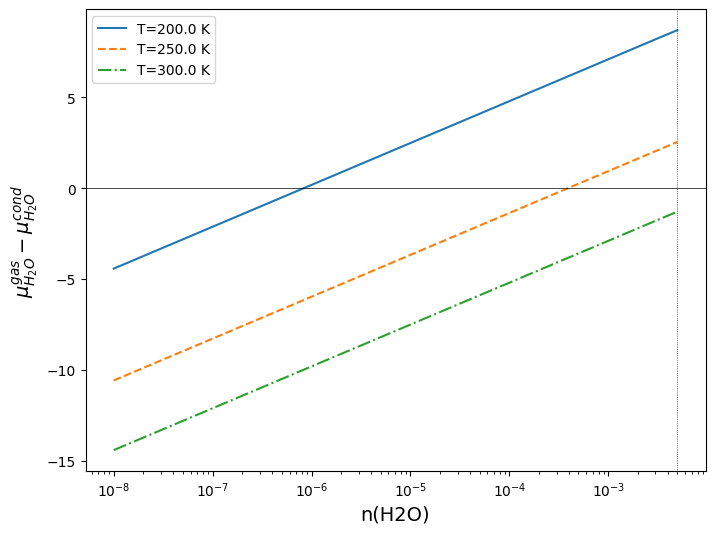

In [39]:
import matplotlib.pyplot as plt
bN = 0.99
bH = 0.01
p = 1.0 # bar
nh2os = np.logspace(-8, np.log10(bH/2), 1000)

plt.figure(figsize=(8,6))
for i, T in enumerate([200.0, 250.0, 300.0]):
    plt.plot(nh2os, h2o_gas_h_values(T, p, nh2os, bN/2)- h2o_cond_h_values(T), label='T='+str(T)+" K", ls=['solid', '--', '-.'][i])
plt.axhline(0.0, color='k', lw=0.5)
plt.axvline(bH/2, color='k', lw=0.5, ls='dotted')
plt.xscale("log")
plt.ylabel("$\mu_{H_2O}^{gas} - \mu_{H_2O}^{cond}$", fontsize=14)
plt.xlabel("n(H2O)", fontsize=14)
plt.legend()
plt.show()


The amount of nH2O can also be verified directly by minimizing the total Gibbs energy.

In [40]:
import numpy as np
def gibbs_energy(T,p, nN2, nH2O, mH2O):
    mu_h2o = h2o_gas_h_values(T, p, nH2O, nN2)
    mu_n2 = n2_gas_h_values(T, p, nH2O, nN2)
    return h2o_cond_h_values(T)*mH2O + mu_h2o*nH2O + mu_n2*nN2

In [48]:

def gibbs_given(nh2o,T,p=1.0):
    return gibbs_energy(T, p, bN/2, nh2o, bH/2 - nh2o)
nmh2o = 0.01


Text(0, 0.5, 'Gibbs energy (relative)')

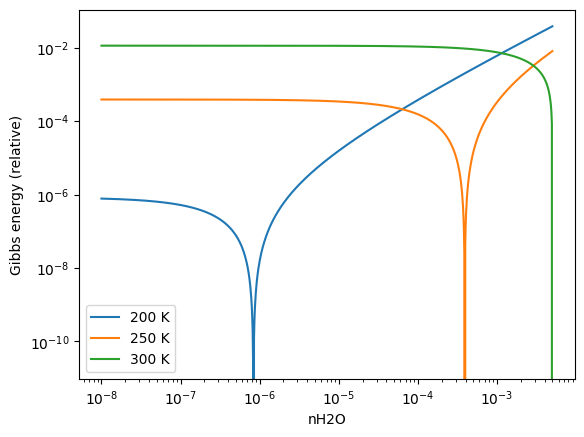

In [53]:
nh2os = np.logspace(-8,np.log10(bH/2),1000)
for T in [200,250,300]:
    plt.plot(nh2os, gibbs_given(nh2os,T) - np.nanmin(gibbs_given(nh2os,T)), label=str(T)+" K")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.xlabel("nH2O")
plt.ylabel("Gibbs energy (relative)")
#plt.xscale("log")

Derive the minimum using a grid search.

In [54]:
def nh2o_gibbs_min(T,p=1.0):
    i = np.nanargmin(gibbs_given(nh2os,T,p))
    return nh2os[i]

In [60]:
from tqdm import tqdm

Parr = np.logspace(-3, 3, 100)
Tarr = np.linspace(100, 500, 100)

nh2os_arr = []
for p in tqdm(Parr):
    mastarr_t = []
    for T in Tarr:
        mastarr_t.append(nh2o_gibbs_min(T, p))
    nh2os_arr.append(mastarr_t)
nh2os_arr = np.array(nh2os_arr)

100%|██████████| 100/100 [00:15<00:00,  6.37it/s]


In [61]:
from exojax.atm.psat import psat_water_AM01 
Psat_arr = psat_water_AM01(Tarr)

The boundary at which a condensate forms can also be determined by dividing the saturation pressure by the maximum partial pressure of H2O gas.

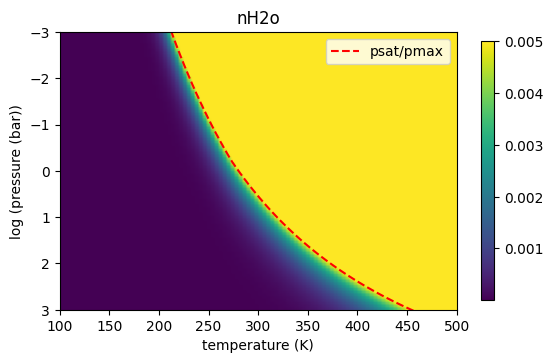

In [62]:
pmax = (bH/2)/(bH/2 + bN/2)  # maximum possible nH2O
fig = plt.figure()
ax = fig.add_subplot(111)
c = ax.imshow(nh2os_arr, extent=(Tarr[0],Tarr[-1],np.log10(Parr[-1]),np.log10(Parr[0])))
plt.plot(Tarr, np.log10(Psat_arr/pmax), color='red', linestyle='dashed', label='psat/pmax')
ax.set_ylim(np.log10(Parr[0]), np.log10(Parr[-1]))
plt.colorbar(c, shrink=0.7)
ax.set_aspect(0.7/ax.get_data_ratio())
plt.gca().invert_yaxis()
ax.set_xlabel("temperature (K)")
ax.set_ylabel("log (pressure (bar))")
ax.set_title("nH2o")
plt.legend()
plt.show()

## minimization using minimize_gibbs_cond_core

In [14]:
from exogibbs.optimize.minimize_cond import minimize_gibbs_cond_core
import jax.numpy as jnp
from exogibbs.api.chemistry import ThermoState

from exogibbs.optimize.core import compute_ln_normalized_pressure


In [15]:

# Thermodynamic conditions
temperature = 500.0  # K
P = 10.0  # bar
Pref = 1.0  # bar, reference pressure
ln_normalized_pressure = compute_ln_normalized_pressure(P, Pref)

# Initial guess for log number densities
ln_etak = jnp.zeros(formula_matrix_cond.shape[1])  # log(eta)
ln_nk = jnp.zeros(formula_matrix_gas.shape[1])  # log(n_species)
ln_mk = jnp.zeros(formula_matrix_cond.shape[1])  # log(n_condensates)
ln_ntot = 0.0  # log(total number density)

fastchem_elements = list(gas.elements)
element_indices = jnp.array([fastchem_elements.index(e) for e in elements])
b_ref = jnp.asarray(gas.element_vector_reference)[element_indices]
# ThermoState instance
thermo_state = ThermoState(
    temperature=temperature,
    ln_normalized_pressure=ln_normalized_pressure,
    element_vector=b_ref,
)

def hvector_cond_func(T): 
    return  jnp.array([cond.hvector_func(T)[index_h2o_cond]])

def hvector_func(T):
    return  jnp.array([gas.hvector_func(T)[index_h2o_gas],gas.hvector_func(T)[index_n2_gas]])

epsilon = -30.0

print(ln_etak, ln_nk, ln_mk, ln_ntot)

[0.] [0. 0.] [0.] 0.0


In [ ]:
temperature = 200.0  # K
P = 1.0  # bar
Pref = 1.0  # bar, reference pressure
ln_normalized_pressure = compute_ln_normalized_pressure(P, Pref)

# Initial guess for log number densities
ln_etak = jnp.zeros(formula_matrix_cond.shape[1])  # log(eta)
ln_nk = jnp.zeros(formula_matrix_gas.shape[1])  # log(n_species)
ln_mk = jnp.zeros(formula_matrix_cond.shape[1])  # log(n_condensates)
ln_ntot = 0.0  # log(total number density)

fastchem_elements = list(gas.elements)
element_indices = jnp.array([fastchem_elements.index(e) for e in elements])
b_ref = jnp.asarray(gas.element_vector_reference)[element_indices]
# ThermoState instance
thermo_state = ThermoState(
    temperature=temperature,
    ln_normalized_pressure=ln_normalized_pressure,
    element_vector=b_ref,
)
epsilon = -30.0
ln_nk, ln_mk, ln_etak, ln_ntot, counter = minimize_gibbs_cond_core(
    thermo_state,
    ln_nk_init=ln_nk,
    ln_mk_init=ln_mk,
    ln_etak_init=ln_etak,
    ln_ntot_init=ln_ntot,
    formula_matrix=formula_matrix_gas,
    formula_matrix_cond=formula_matrix_cond,
    hvector_func=hvector_func,
    hvector_cond_func=hvector_cond_func,
    epsilon=epsilon,  ### new argument
    residual_crit=1.0e-11,
    max_iter=1,
    element_indices=element_indices,
)

print(ln_etak, ln_nk, ln_mk, ln_ntot)

[nan] [nan nan] [nan] 0.37057664408441726
